Optimal Path Discovered:
Gateway of India -> Marine Drive -> Haji Ali -> Lower Parel -> Dadar -> Mahim -> Bandra Bandstand

Total Road Distance: 25 km


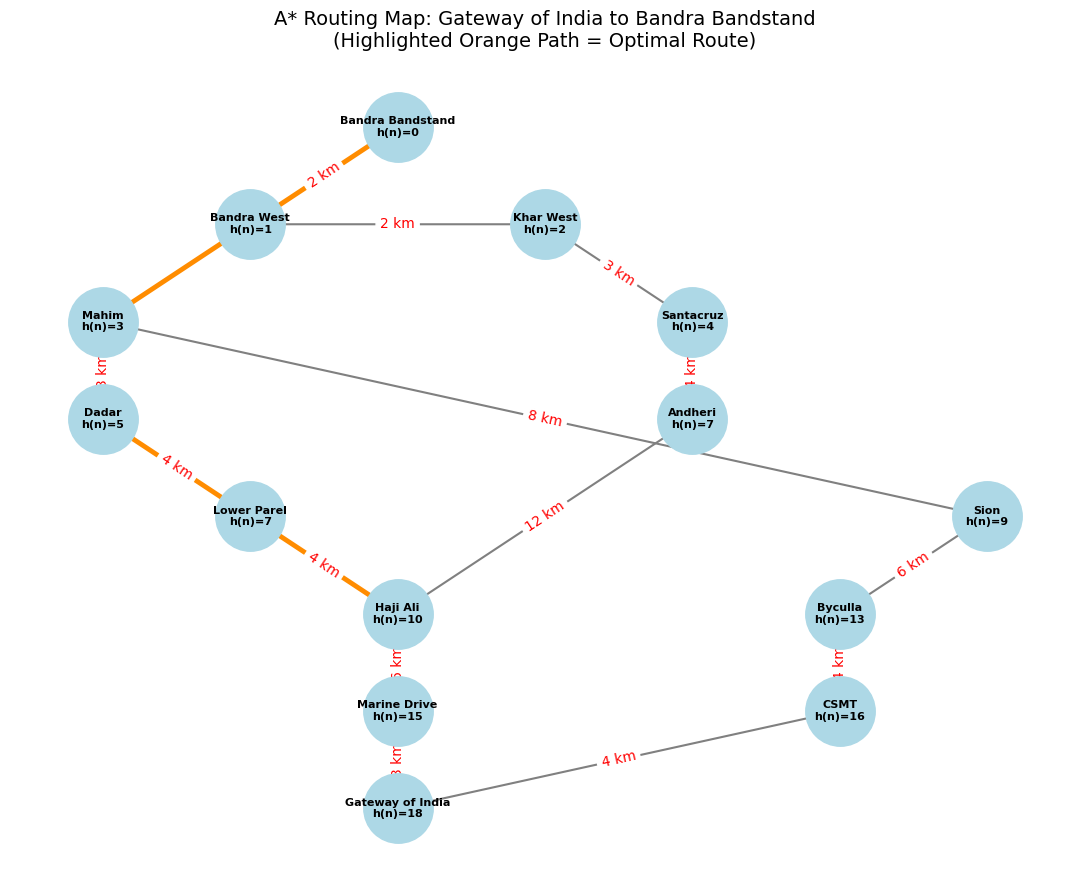

In [ ]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------------------------------------------------
# 1. DATA STRUCTURE POPULATION
# -------------------------------------------------------------------------

# Actual Road Distance g(n) between interconnected nodes
graph = {
    'Gateway of India': {
        'Marine Drive': 3,
        'CSMT': 4
    },

    'Marine Drive': {
        'Haji Ali': 6
    },

    'CSMT': {
        'Byculla': 4
    },

    'Haji Ali': {
        'Lower Parel': 4,
        'Andheri': 12
    },

    'Byculla': {
        'Sion': 6
    },

    'Lower Parel': {
        'Dadar': 4
    },

    'Andheri': {
        'Santacruz': 4
    },

    'Sion': {
        'Mahim': 8
    },

    'Dadar': {
        'Mahim': 3
    },

    'Santacruz': {
        'Khar West': 3
    },

    'Mahim': {
        'Bandra Bandstand': 5
    },

    'Khar West': {
        'Bandra West': 2
    },

    'Bandra West': {
        'Bandra Bandstand': 2
    },

    'Bandra Bandstand': {}
}

# Straight-line Heuristic Distance h(n) to Bandra Bandstand
heuristics = {
    'Gateway of India': 16,
    'Marine Drive': 13,
    'CSMT': 14,
    'Haji Ali': 10,
    'Byculla': 11,
    'Lower Parel': 7,
    'Andheri': 6,
    'Sion': 8,
    'Dadar': 5,
    'Santacruz': 4,
    'Mahim': 3,
    'Khar West': 2,
    'Bandra West': 1,
    'Bandra Bandstand': 0
}

# Rough spatial coordinates for plotting
node_positions = {
    'Gateway of India': (6, 0),
    'Marine Drive': (6, 2),
    'CSMT': (9, 2),
    'Haji Ali': (6, 4),
    'Byculla': (9, 4),
    'Lower Parel': (5, 6),
    'Sion': (10, 6),
    'Dadar': (4, 8),
    'Andheri': (8, 8),
    'Mahim': (4, 10),
    'Santacruz': (8, 10),
    'Khar West': (7, 12),
    'Bandra West': (5, 12),
    'Bandra Bandstand': (6, 14)
}

# -------------------------------------------------------------------------
# 2. A* SEARCH ALGORITHM
# -------------------------------------------------------------------------

def a_star_search(graph, heuristics, start, goal):

    # Priority Queue stores:
    # (f_score, current_node, path_taken, cumulative_g_score)

    priority_queue = [(heuristics[start], start, [start], 0)]

    visited = set()

    while priority_queue:

        f_score, current, path, g_score = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)

        if current == goal:
            return path, g_score

        for neighbor, edge_weight in graph[current].items():

            if neighbor not in visited:

                next_g = g_score + edge_weight
                next_f = next_g + heuristics[neighbor]

                heapq.heappush(
                    priority_queue,
                    (next_f, neighbor, path + [neighbor], next_g)
                )

    return None, float('inf')


# -------------------------------------------------------------------------
# 3. RUN THE ALGORITHM
# -------------------------------------------------------------------------

optimal_path, total_distance = a_star_search(
    graph,
    heuristics,
    'Gateway of India',
    'Bandra Bandstand'
)

print("Optimal Path Discovered:")
print(" -> ".join(optimal_path))
print(f"\nTotal Road Distance: {total_distance} km")

# -------------------------------------------------------------------------
# 4. GRAPH VISUALIZATION
# -------------------------------------------------------------------------

G = nx.DiGraph()

for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(11, 9))

path_edges = list(zip(optimal_path, optimal_path[1:]))

normal_edges = [
    edge for edge in G.edges()
    if edge not in path_edges
]

# Draw Nodes
nx.draw_networkx_nodes(
    G,
    node_positions,
    node_size=2500,
    node_color='lightblue'
)

# Draw Normal Edges
nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=normal_edges,
    width=1.5,
    edge_color='gray',
    arrows=True
)

# Highlight Optimal Path
nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=path_edges,
    width=3.5,
    edge_color='darkorange',
    arrows=True
)

# Node Labels
node_labels = {
    node: f"{node}\nh(n)={heuristics[node]}"
    for node in G.nodes()
}

nx.draw_networkx_labels(
    G,
    node_positions,
    labels=node_labels,
    font_size=8,
    font_weight='bold'
)

# Edge Labels
edge_labels = nx.get_edge_attributes(G, 'weight')

formatted_edge_labels = {
    edge: f"{weight} km"
    for edge, weight in edge_labels.items()
}

nx.draw_networkx_edge_labels(
    G,
    node_positions,
    edge_labels=formatted_edge_labels,
    font_color='red'
)

plt.title(
    "A* Routing Map: Gateway of India to Bandra Bandstand\n"
    "(Highlighted Orange Path = Optimal Route)",
    fontsize=14
)

plt.axis('off')
plt.tight_layout()
plt.show()